In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from allensdk.brain_observatory.behavior.behavior_project_cache.\
    behavior_neuropixels_project_cache \
    import VisualBehaviorNeuropixelsProjectCache

%matplotlib inline

Loading the Data

In [2]:
# Update this to a valid directory in your filesystem. This is where the data will be stored.
cache_dir = '../data/'

cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=cache_dir) #from_s3_cache(cache_dir=cache_dir)

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\allensdk\api\cloud_cache\cloud_cache.py:547: OutdatedManifestWarning: You are loading visual-behavior-neuropixels_project_manifest_v0.5.0.json. A more up to date version of the dataset -- visual-behavior-ophys_project_manifest_v1.1.0.json -- exists online. To see the changes between the two versions of the dataset, run
VisualBehaviorNeuropixelsProjectCache.compare_manifests('visual-behavior-neuropixels_project_manifest_v0.5.0.json', 'visual-behavior-ophys_project_manifest_v1.1.0.json')
To load another version of the dataset, run
VisualBehaviorNeuropixelsProjectCache.load_manifest('visual-behavior-ophys_project_manifest_v1.1.0.json')
  warnings.warn(msg, OutdatedManifestWarning)


In [3]:
# get the metadata tables
units_table = cache.get_unit_table()

channels_table = cache.get_channel_table()

probes_table = cache.get_probe_table()

behavior_sessions_table = cache.get_behavior_session_table()

ecephys_sessions_table = cache.get_ecephys_session_table()

Choose A Session

In [5]:
session_id = 1064644573
session = cache.get_ecephys_session(
            ecephys_session_id=session_id)

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:772: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


In [60]:
# Get Neural Data
units = session.get_units()
channels = session.get_channels()

unit_channels = units.merge(channels, left_on='peak_channel_id', right_index=True)

#first let's sort our units by depth
unit_channels = unit_channels.sort_values('probe_vertical_position', ascending=False)

#now we'll filter them
good_unit_filter = ((unit_channels['snr']>1)&
                    (unit_channels['isi_violations']<1)&
                    (unit_channels['firing_rate']>0.1))

good_units = unit_channels.loc[good_unit_filter]

spike_times = session.spike_times

# Stimulus Data
stimulus_presentations = session.stimulus_presentations
change_times = stimulus_presentations[stimulus_presentations['active']&
                            stimulus_presentations['is_change']]['start_time'].values

# Behavioral Data
eye_tracking = session.eye_tracking
running_speed = session.running_speed
licks = session.licks

In [61]:
len(good_units), len(spike_times)

(1640, 2254)

In [ ]:
# Get max and min times (NOTE: THIS SHOULD BE FIXED TO JUST USE THE TIMES OF THE ACTIVE BLOCK)
min_t = 9999
max_t = -9999
for st in spike_times.values():
    min_t = min(st.min(), min_t)
    max_t = max(st.max(), max_t)
min_t, max_t

(4.972960198839347, 9544.760292052171)

In [ ]:
binSize = 0.25 # Can change this to any number of seconds
bins = np.arange(min_t, max_t+binSize, binSize)
len(bins)

38161

In [ ]:
#Here's where we loop through the units in our area of interest
area_of_interest = 'VISp'
area_change_responses = []
area_units = good_units[good_units['structure_acronym']==area_of_interest]
for iu, unit in area_units.iterrows():
    unit_spike_times = spike_times[iu]
    counts = np.histogram(spike_times[iu], bins)[0]
    unit_change_response = counts
    area_change_responses.append(unit_change_response)
area_change_responses = np.array(area_change_responses)

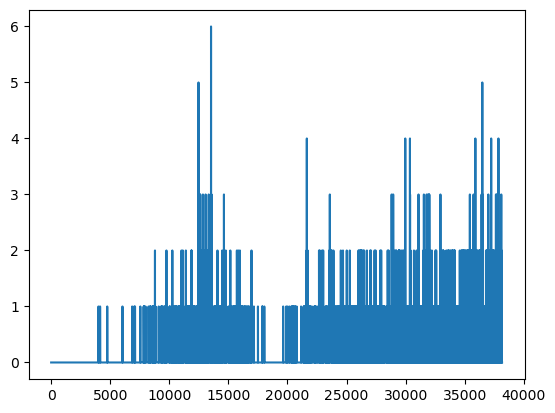

In [152]:
plt.plot(area_change_responses[4])

Examples of Fitting

In [154]:
from sklearn.linear_model import LinearRegression
X = area_change_responses[1:].T
# y = 1 * x_0 + 2 * x_1 + 3
y = area_change_responses[:1].T
reg = LinearRegression().fit(X, y)
y_hat = reg.predict(X)
reg.score(X, y)

0.20353103902197933

In [ ]:
# I couldn't get this to run quickly, but maybe you can

# from sklearn.kernel_ridge import KernelRidge
# import numpy as np
# rng = np.random.RandomState(0)
# krr = KernelRidge(alpha=1.0)
# krr.fit(X, y)
# y_hat_krr = reg.predict(X)
# krr.score(X, y)

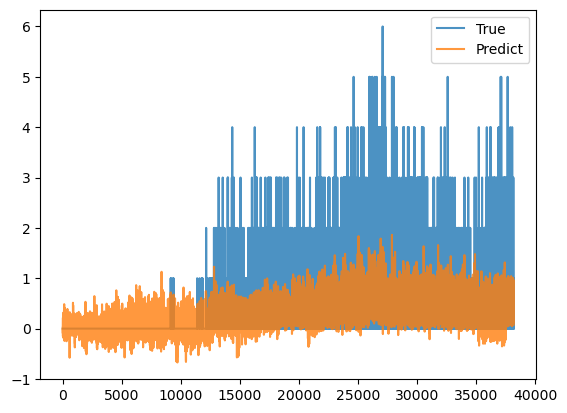

In [156]:
plt.plot(y, alpha=0.8, label="True")
plt.plot(y_hat, alpha=0.8, label="Predict")
plt.legend()
plt.show()

In [146]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=2, n_init="auto").fit(area_change_responses)
kmeans.labels_

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1])

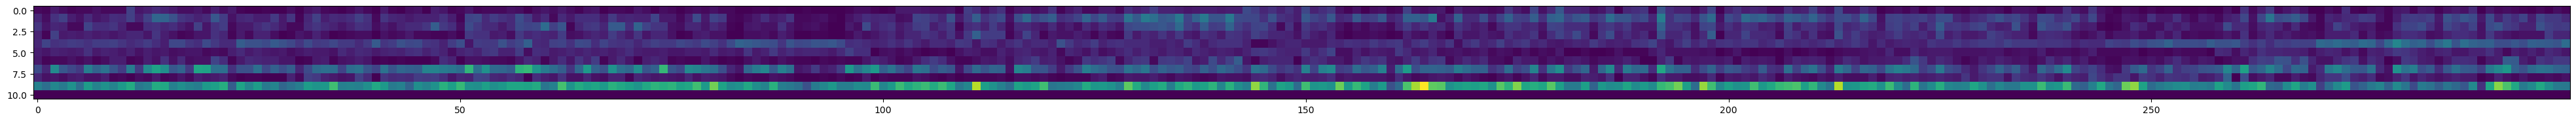

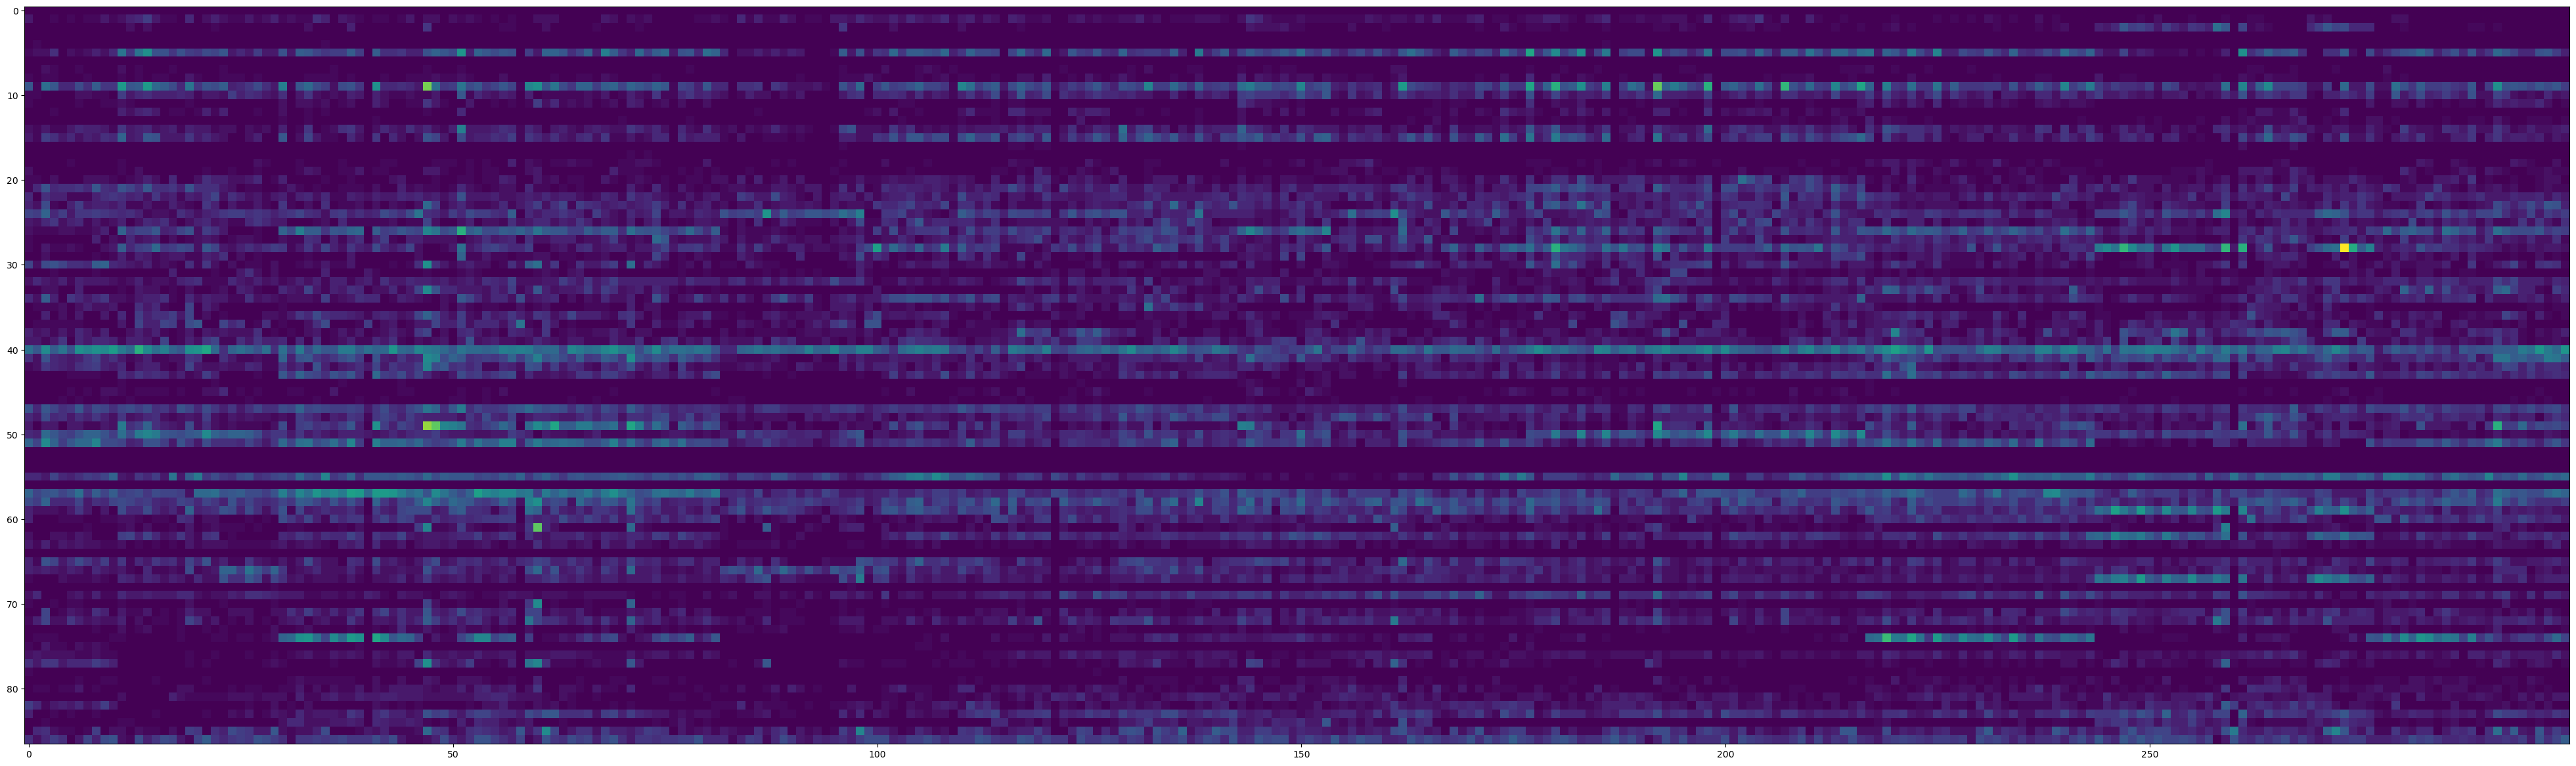

In [147]:
for i in range(2):
    fig = plt.figure(figsize=(50,50))
    plt.imshow(area_change_responses[kmeans.labels_==i, 1000:1300])
    plt.show()